### Importación de Librerías
Importamos las bibliotecas necesarias: `numpy` para cálculos numéricos, `matplotlib` para gráficos, `skimage` para procesamiento de imágenes y `sklearn` para los algoritmos de Machine Learning.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, morphology, exposure
from skimage.util import img_as_ubyte
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import jaccard_score, accuracy_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Conexión con Google Drive
Montamos la unidad de Google Drive en el entorno de Colab para poder acceder a los archivos del dataset.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Función de Extracción de Características
Define la función `extraer_caracteristicas_pixel`. Convierte cada imagen original en una matriz de 13 características aplicando filtros matemáticos (Sobel, Hessiano, Entropía, etc.) para resaltar bordes y texturas.

Nota: He añadido el parámetro `use_gaussian_derivatives=False` a la variable `H_elems` para que no salga el **Warning** a la hora de procesar y cargar las imágenes.

In [3]:
def normalizar_car(array):
    min_val = np.min(array)
    max_val = np.max(array)
    if max_val - min_val == 0: return array
    return (array - min_val) / (max_val - min_val)

def extraer_caracteristicas_pixel(image_rgb):
    caracteristicas = []
    # Preprocesado

    #equalize_adapthist implementa el algoritmo CLAHE: Mejora el contraste de forma local.
    #A diferencia de una ecualización global,
    #esta evita saturar áreas brillantes y ayuda a resaltar detalles en sombras.
    img_eq = exposure.equalize_adapthist(image_rgb, clip_limit=0.03)

    # Filtro gausiano. Aplica un desenfoque para reducir el ruido de alta frecuencia,
    # asegurando que los filtros posteriores
    # no interpreten ruido aleatorio como información relevante.
    img_smooth = filters.gaussian(img_eq, sigma=1, channel_axis=-1)


    gray = color.rgb2gray(img_smooth)

    #HSV Saturación. separar objetos por la pureza de su color,
    hsv = color.rgb2hsv(img_smooth)
    #Lab (a, b) El espacio Lab separa la luminosidad L de los componentes de color a y b.
    lab = color.rgb2lab(img_smooth)

    # recolectamos las características
    caracteristicas.append(img_smooth[:,:,0])
    caracteristicas.append(img_smooth[:,:,1])
    caracteristicas.append(img_smooth[:,:,2])
    caracteristicas.append(hsv[:,:,1])
    caracteristicas.append(normalizar_car(lab[:,:,1]))
    caracteristicas.append(normalizar_car(lab[:,:,2]))

    #Filtro Sobel. Calcula el gradiente de intensidad.
    #Resalta los bordes verticales y horizontales.
    #Sirve para encontrar siluetas
    edge_sobel = filters.sobel(gray)
    caracteristicas.append(normalizar_car(edge_sobel))

    # DoG (Difference of Gaussians)
    # Se obtiene restando una versión muy desenfocada de la imagen de una menos desenfocada.
    # Actúa como un filtro de paso de banda que resalta detalles y bordes
    dog = filters.gaussian(gray, sigma=1) - filters.gaussian(gray, sigma=8)
    caracteristicas.append(normalizar_car(dog))

    # Filtro Frangi
    # Este filtro está diseñado específicamente para detectar estructuras tubulares
    # o filamentosas (como vasos sanguíneos, carreteras o fibras).
    # Utiliza los autovalores de la matriz Hessiana para determinar como de parecido a un tubo es un píxel.
    frangi = filters.frangi(gray, sigmas=range(1, 4), black_ridges=False)
    caracteristicas.append(normalizar_car(frangi))

    # Matriz Hessiana
    # Se calcula a dos escalas (1.5 y 3.5). La matriz Hessiana mide la curvatura local de la intensidad de la imagen.
    # Los autovalores (eigenvalues) resultantes te dicen si estás en una zona plana, en una cresta (borde) o en un rincón.
    # Al extraer eigvals[0], estás capturando la curvatura principal de la superficie de la imagen.

    for escala in [1.5, 3.5]:
        H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc', use_gaussian_derivatives=False)
        eigvals = feature.hessian_matrix_eigvals(H_elems)
        caracteristicas.append(normalizar_car(eigvals[0]))

    gray_ubyte = img_as_ubyte(gray)
    #mide el desorden o complejidad de las texturas de las que el pixel forma parte
    entropy = filters.rank.entropy(gray_ubyte, morphology.disk(3))
    caracteristicas.append(normalizar_car(entropy))

    #Este filtro resalta los limites de los objetos
    morph_grad = filters.rank.gradient(gray_ubyte, morphology.disk(2))
    caracteristicas.append(normalizar_car(morph_grad))

    return np.stack(caracteristicas, axis=-1)


### Función de Procesamiento de Imágenes
Definimos `procesar_lista_imagenes`, que lee una lista de archivos, extrae sus características y realiza un submuestreo aleatorio (toma solo un porcentaje de píxeles) para crear los datos de entrenamiento sin saturar la memoria.

In [4]:
def procesar_lista_imagenes(lista_sat, lista_gt, muestra_pixels=0.02):
    """
    Procesa una lista específica de archivos y devuelve X e y.
    """
    X_list = []
    y_list = []

    print(f"Procesando {len(lista_sat)} imágenes...")

    for i, (f_sat, f_gt) in enumerate(zip(lista_sat, lista_gt)):
        print(f"  -> {os.path.basename(f_sat)}")

        # Cargamos imagen y etiqueta
        img = io.imread(f_sat)
        mask = io.imread(f_gt, as_gray=True)

        # Convertimos máscara a binario (0 y 1) estrictamente
        mask = (mask > 0).astype(int)

        # Extraemos características (13 canales)
        features = extraer_caracteristicas_pixel(img)

        # Aplanamos las matrices para que cada fila sea un pixel
        h, w, c = features.shape
        features_flat = features.reshape(-1, c) # (N_pixels, 13)
        mask_flat = mask.reshape(-1) # (N_pixels,)

        # Submuestreo (Sampling) para evitar colapso de memoria
        # Tomamos aleatoriamente un % de los píxeles de esta imagen
        n_muestras = int(features_flat.shape[0] * muestra_pixels)
        indices = np.random.choice(features_flat.shape[0], n_muestras, replace=False)

        X_list.append(features_flat[indices])
        y_list.append(mask_flat[indices])

    if not X_list:
        return np.array([]), np.array([])

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y

### Definición de la Ruta del Dataset
Establecemos la variable `DIR_DATASET` con la ruta de la carpeta en Google Drive donde se encuentran almacenadas las imágenes satelitales y las máscaras.

In [5]:
# Definimos ruta
DIR_DATASET = "/content/drive/MyDrive/Archivos .csv/Dataset_Carretera/roads"

### Obtención de Archivos
Buscamos y listamos todas las imágenes satelitales (`sat`) y sus correspondientes máscaras (`gt`) usando `glob`, ordenándolas alfabéticamente para asegurar que coincidan pares.

In [6]:
# Obtenemos todas las rutas ordenadas
all_sat = sorted(glob.glob(os.path.join(DIR_DATASET, "sat", "*.tiff")))
all_gt = sorted(glob.glob(os.path.join(DIR_DATASET, "gt", "*.tif")))

# Verificación de seguridad
if len(all_sat) < 20:
    print(f"¡Cuidado! Solo se encontraron {len(all_sat)} imágenes. Se ajustará el split automáticamente.")

# División Manual (16 Train / 4 Test)
# Nota: Si hay menos de 20 imágenes, coge las últimas 4 para test y el resto para train
split_point = max(1, len(all_sat) - 4)

train_sat = all_sat[:split_point]
train_gt = all_gt[:split_point]

test_sat = all_sat[split_point:]
test_gt = all_gt[split_point:]

### División del Dataset (Train/Test)
Separamos la lista de archivos en dos conjuntos estrictos: las primeras 16 imágenes se usarán para Entrenamiento y las últimas 4 se reservan para el Test. Mostramos en pantalla el recuento.

In [7]:
print(f"Dataset Split")
print(f"Total imágenes: {len(all_sat)}")
print(f"Imágenes de ENTRENAMIENTO: {len(train_sat)} (Indices 0 a {split_point-1})")
print(f"Imágenes de TEST: {len(test_sat)} (Indices {split_point} a {len(all_sat)-1})")

Dataset Split
Total imágenes: 20
Imágenes de ENTRENAMIENTO: 16 (Indices 0 a 15)
Imágenes de TEST: 4 (Indices 16 a 19)


### Generación de Datos de Entrenamiento
Llamamos a la función de procesamiento para las 16 imágenes de entrenamiento, extrayendo el 2% de los píxeles de cada una para construir la matriz `X_train`.

In [8]:
# Generamos las matrices
# Para el entrenamiento usamos 2% de píxeles para no saturar la memoria
print("Generando matriz de ENTRENAMIENTO...")
X_train, y_train = procesar_lista_imagenes(train_sat, train_gt, muestra_pixels=0.02)

Generando matriz de ENTRENAMIENTO...
Procesando 16 imágenes...
  -> 10078675_15.tiff
  -> 10228675_15.tiff
  -> 10228705_15.tiff
  -> 10228720_15.tiff
  -> 10228735_15.tiff
  -> 10228750_15.tiff
  -> 10378675_15.tiff
  -> 10378690_15.tiff
  -> 10378705_15.tiff
  -> 10378720_15.tiff
  -> 10378735_15.tiff
  -> 10378750_15.tiff
  -> 10378765_15.tiff
  -> 10528675_15.tiff
  -> 10528690_15.tiff
  -> 10528705_15.tiff


### Generación de Datos de Prueba
Procesamos las 4 imágenes de prueba (también con submuestreo) para crear la matriz `X_test`, que se usará para calcular las métricas de rendimiento de forma rápida.

In [9]:
# Para el conjunto de prueba también submuestreamos
print("Generando matriz de TEST (muestreo para métricas)...")
X_test, y_test = procesar_lista_imagenes(test_sat, test_gt, muestra_pixels=0.05) # Un poco más denso para test

Generando matriz de TEST (muestreo para métricas)...
Procesando 4 imágenes...
  -> 10528720_15.tiff
  -> 10528735_15.tiff
  -> 10528750_15.tiff
  -> 10528765_15.tiff


### Verificación de Dimensiones
Imprimimos el tamaño final de las matrices de entrenamiento y test para confirmar que los datos se han cargado correctamente antes de entrenar.

In [10]:
# Mostramos las dimensiones finales
print(f"Dimensiones finales -> X_train: {X_train.shape}, X_test: {X_test.shape}")

Dimensiones finales -> X_train: (720000, 13), X_test: (450000, 13)


### Definición de Modelos
Inicializamos los clasificadores: Random Forest, SVM (configurado con pesos balanceados para corregir el desequilibrio de clases) y KNN (K-Vecinos Cercanos).

In [11]:
# Modelos
modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=15, # Evita memorizar el ruido
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', cache_size=2000, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

resultados = {}

### Entrenamiento y Evaluación
Entrenamos a cada modelo con `X_train`, realizamos las predicciones sobre `X_test` y calculamos las métricas de rendimiento (Accuracy, Jaccard y F1-Score) para compararlos.

In [12]:
print("Comienzo del entrenamiento")

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")

    # Ajuste de datos para SVM si es muy grande
    if "SVM" in nombre and len(X_train) > 10000:
            print(" (Submuestreando Train para SVM por velocidad...)")
            idx_svm = np.random.choice(len(X_train), 10000, replace=False)
            modelo.fit(X_train[idx_svm], y_train[idx_svm])
    else:
        modelo.fit(X_train, y_train)

    # Predicción sobre el set de test (píxeles sueltos de las 4 imágenes reservadas)
    print(f"Evaluando {nombre}...")
    y_pred = modelo.predict(X_test)

     # Métricas
    acc = accuracy_score(y_test, y_pred)
    jac = jaccard_score(y_test, y_pred) # Jaccard Score para clase 1
    f1 = f1_score(y_test, y_pred)

    resultados[nombre] = {"Accuracy": acc, "Jaccard": jac, "F1-Score": f1}
    print(f"  -> Accuracy: {acc:.4f}, Jaccard: {jac:.4f}, F1: {f1:.4f}")

Comienzo del entrenamiento
Entrenando Random Forest...
Evaluando Random Forest...
  -> Accuracy: 0.8932, Jaccard: 0.2678, F1: 0.4225
Entrenando SVM (RBF)...
 (Submuestreando Train para SVM por velocidad...)
Evaluando SVM (RBF)...
  -> Accuracy: 0.8229, Jaccard: 0.1981, F1: 0.3307
Entrenando KNN (k=5)...
Evaluando KNN (k=5)...
  -> Accuracy: 0.9488, Jaccard: 0.1776, F1: 0.3017


### Reducción de Dimensionalidad (PCA)
Estandarizamos los datos y aplicamos PCA para reducir las 13 características originales a 8 componentes principales, eliminando redundancia.

In [13]:
print("Evaluando con PCA")
scaler = StandardScaler()
# Ajustamos scaler solo con train
scaler.fit(X_train)

# Estandarizamos antes de PCA
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Aplicamos PCA para reducir de 13 a 8 componentes principales
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

print(f"Varianza explicada (8 comp): {np.sum(pca.explained_variance_ratio_):.2f}")

Evaluando con PCA
Varianza explicada (8 comp): 0.97


### Entrenamiento con PCA
Entrenamos un nuevo modelo Random Forest utilizando los datos reducidos (8 características) y evaluamos su rendimiento para ver si mantiene la calidad con menos datos.

In [14]:
# Re-entrenamos Random Forest con datos reducidos
rf_pca = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

jac_pca = jaccard_score(y_test, y_pred_pca)
print(f"Random Forest con PCA -> Jaccard: {jac_pca:.4f}")

Random Forest con PCA -> Jaccard: 0.1006


### Comparación Visual (RF vs RF+PCA)
Tomamos una imagen completa del test, predecimos el mapa de carreteras usando el Random Forest completo y el Random Forest con PCA, y mostramos ambos resultados para comparar la calidad visual.

### Evaluación de la Reducción de Dimensionalidad
Realizamos una comparación directa entre el modelo **Random Forest original** (que usa las 13 características completas) y el **Random Forest con PCA** (que usa solo las 8 características comprimidas).

**¿Qué estamos evaluando?**
Verificamos el impacto de la compresión de datos:
* Si la imagen de la derecha (PCA) se ve similar a la del centro (RF Completo), significa que la reducción ha sido exitosa: hemos eliminado redundancia sin perder información vital.
* Si el PCA se ve mucho peor, significaría que las 8 componentes no fueron suficientes para capturar la complejidad de la carretera.
* A veces, el PCA se ve incluso más "limpio" porque ha eliminado el ruido de los filtros individuales.

Comparando RF Completo vs RF con PCA
Imagen: 10528765_15.tiff
Generando predicción RF Completo...
Generando predicción RF con PCA...


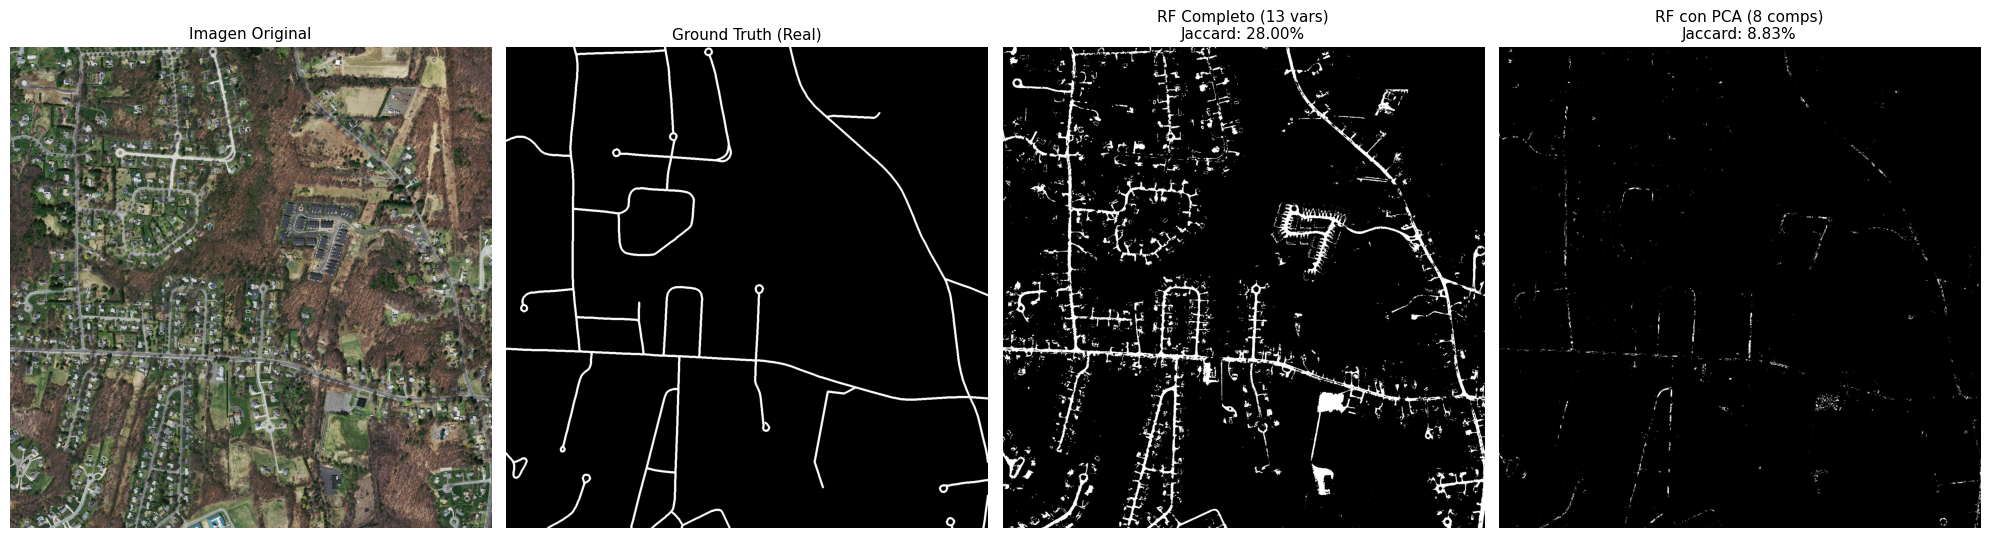

In [15]:
# COMPARACIÓN VISUAL: RANDOM FOREST (13 características) vs RF + PCA (8 componentes)

if len(test_sat) > 0 and 'rf_pca' in locals():
    # Seleccionamos la imagen de Test
    idx_viz = 3  # Podemos cambiar este índice (0, 1, 2, 3)
    file_viz_sat = test_sat[idx_viz]
    file_viz_gt = test_gt[idx_viz]

    print(f"Comparando RF Completo vs RF con PCA")
    print(f"Imagen: {os.path.basename(file_viz_sat)}")

    # Cargamos la imagen y la máscara
    img_demo = io.imread(file_viz_sat)
    mask_demo = io.imread(file_viz_gt, as_gray=True)
    mask_demo = (mask_demo > 0).astype(int)

    # Extraemos características base (13 canales)
    feat_demo = extraer_caracteristicas_pixel(img_demo)
    h, w, c = feat_demo.shape
    feat_flat = feat_demo.reshape(-1, c)

    # Random Forest COMPLETO
    print("Generando predicción RF Completo...")
    pred_full_flat = modelos["Random Forest"].predict(feat_flat)
    pred_full_img = pred_full_flat.reshape(h, w)
    jac_full = jaccard_score(mask_demo.flatten(), pred_full_img.flatten())

    # Random Forest con PCA
    print("Generando predicción RF con PCA...")
    # Aplicamos Scaler + PCA
    # Estandarizamos
    feat_scaled = scaler.transform(feat_flat)
    # Reducimos dimensiones
    feat_pca_trans = pca.transform(feat_scaled)

    pred_pca_flat = rf_pca.predict(feat_pca_trans)
    pred_pca_img = pred_pca_flat.reshape(h, w)
    jac_pca = jaccard_score(mask_demo.flatten(), pred_pca_img.flatten())

    # VISUALIZACIÓN
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))

    # Original
    ax[0].imshow(img_demo)
    ax[0].set_title("Imagen Original", fontsize=11)
    ax[0].axis('off')

    # Ground Truth
    ax[1].imshow(mask_demo, cmap='gray')
    ax[1].set_title("Ground Truth (Real)", fontsize=11)
    ax[1].axis('off')

    # RF Completo
    ax[2].imshow(pred_full_img, cmap='gray')
    ax[2].set_title(f"RF Completo (13 vars)\nJaccard: {jac_full:.2%}", fontsize=11)
    ax[2].axis('off')

    # RF con PCA
    ax[3].imshow(pred_pca_img, cmap='gray')
    ax[3].set_title(f"RF con PCA (8 comps)\nJaccard: {jac_pca:.2%}", fontsize=11)
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Error: Asegúrate de haber ejecutado las celdas de entrenamiento PCA primero.")

### Visualización Final Multi-Modelo
Generamos la comparativa final: procesamos una imagen de test completa y mostramos las predicciones de los tres modelos (RF, SVM, KNN) junto con la imagen real y la etiqueta original.


Generando Super-Comparativa: Modelos Base vs Postprocesados
Imagen: 10528765_15.tiff
Nota: Esto tardará un par de minutos al tener que predecir y limpiar 3 modelos...
Prediciendo y limpiando con Random Forest...
Prediciendo y limpiando con SVM (RBF)...
Prediciendo y limpiando con KNN (k=5)...


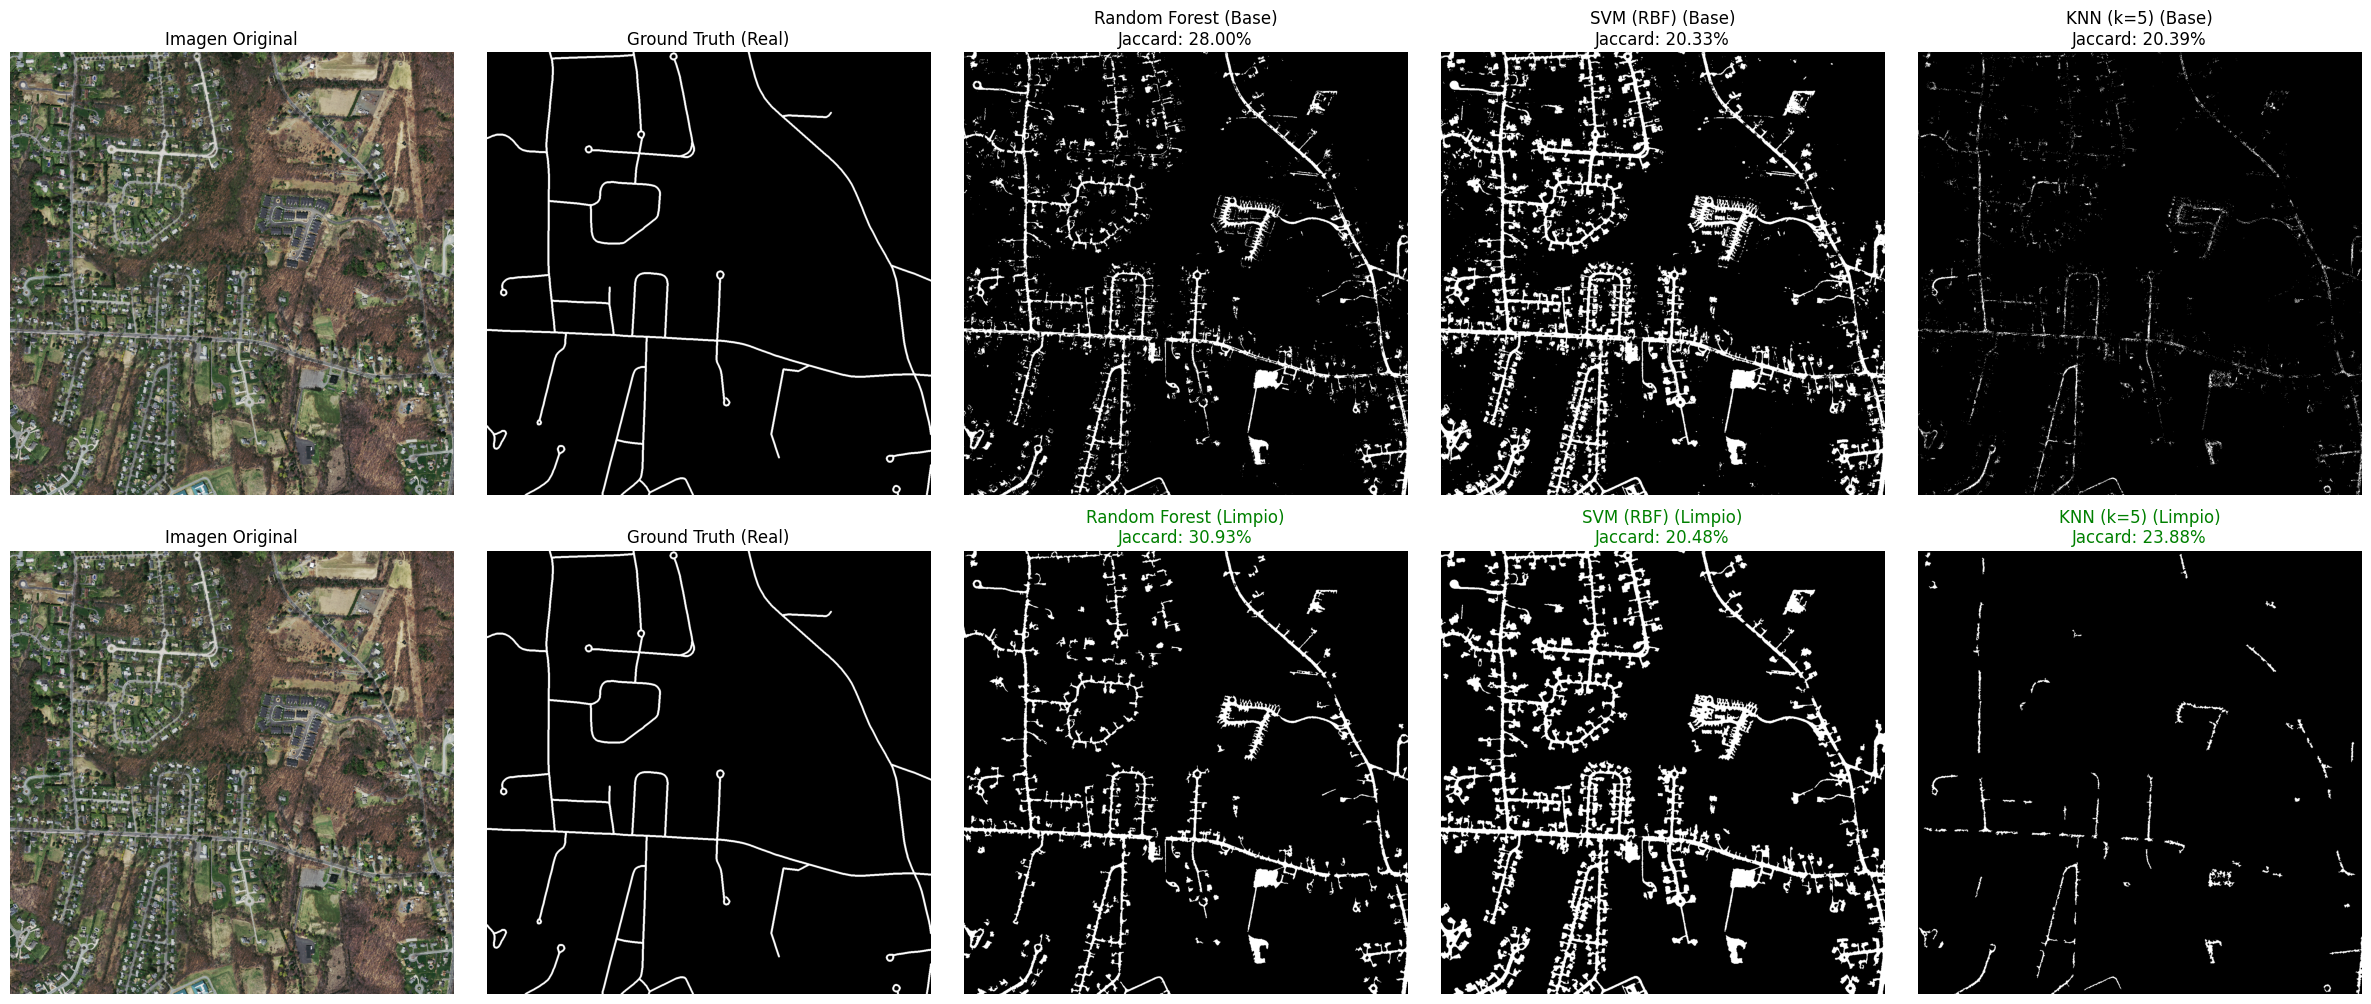

In [16]:
# VISUALIZACIÓN DEFINITIVA: LOS 3 MODELOS (SIN Y CON POSTPROCESADO)

if len(test_sat) > 0:
    # Preparamos la imagen de Test
    idx_viz = 3
    file_viz_sat = test_sat[idx_viz]
    file_viz_gt = test_gt[idx_viz]

    print(f"\nGenerando Super-Comparativa: Modelos Base vs Postprocesados")
    print(f"Imagen: {os.path.basename(file_viz_sat)}")
    print("Nota: Esto tardará un par de minutos al tener que predecir y limpiar 3 modelos...")

    # Cargamos la imagen
    img_demo = io.imread(file_viz_sat)
    mask_demo = io.imread(file_viz_gt, as_gray=True)
    mask_demo = (mask_demo > 0).astype(int)

    # Extraemos las características
    feat_demo = extraer_caracteristicas_pixel(img_demo)
    h, w, c = feat_demo.shape
    feat_flat = feat_demo.reshape(-1, c)

    # Configuramos el gráfico
    fig, axes = plt.subplots(2, 5, figsize=(24, 10))

    # SIN POSTPROCESADO
    axes[0, 0].imshow(img_demo)
    axes[0, 0].set_title("Imagen Original", fontsize=12)

    axes[0, 1].imshow(mask_demo, cmap='gray')
    axes[0, 1].set_title("Ground Truth (Real)", fontsize=12)

    # CON POSTPROCESADO
    axes[1, 0].imshow(img_demo)
    axes[1, 0].set_title("Imagen Original", fontsize=12)

    axes[1, 1].imshow(mask_demo, cmap='gray')
    axes[1, 1].set_title("Ground Truth (Real)", fontsize=12)

    # Iteramos sobre los modelos
    for i, (nombre, modelo) in enumerate(modelos.items()):
        col_idx = i + 2
        print(f"Prediciendo y limpiando con {nombre}...")

        # PREDICCIÓN CRUDA
        pred_flat = modelo.predict(feat_flat)
        pred_raw = pred_flat.reshape(h, w)
        jac_raw = jaccard_score(mask_demo.flatten(), pred_flat)

        axes[0, col_idx].imshow(pred_raw, cmap='gray')
        axes[0, col_idx].set_title(f"{nombre} (Base)\nJaccard: {jac_raw:.2%}", fontsize=12)

        # PREDICCIÓN POSTPROCESADA
        pred_post = pred_raw.astype(bool)

        # Rellenamos agujeros negros DENTRO de la carretera (no afecta al exterior)
        pred_post = morphology.remove_small_holes(pred_post, area_threshold=30)

        # Cierre más suave para no engordar la línea y salvar el Jaccard
        pred_post = morphology.binary_closing(pred_post, morphology.disk(2))

        # Borrado de ruido
        pred_post = morphology.remove_small_objects(pred_post, min_size=150)

        jac_post = jaccard_score(mask_demo.flatten(), pred_post.flatten())

        # Color del título de Jaccard dependiendo de si mejora o empeora
        color_texto = "green" if jac_post > jac_raw else "red" if jac_post < jac_raw else "black"

        axes[1, col_idx].imshow(pred_post, cmap='gray')
        axes[1, col_idx].set_title(f"{nombre} (Limpio)\nJaccard: {jac_post:.2%}", fontsize=12, color=color_texto)

    # Apagamos los ejes (las rayitas de los bordes) para que quede limpio
    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout(h_pad=3.0)
    plt.show()

else:
    print("No hay imágenes de test definidas.")

### Conclusiones del Proyecto

Tras evaluar el rendimiento de los tres modelos (Random Forest, SVM y KNN) junto con las técnicas de reducción de dimensionalidad y postprocesado morfológico, se extraen las siguientes conclusiones clave:

**1. El Impacto del Desbalanceo de Clases**
El análisis exploratorio reveló un desbalanceo extremo en el conjunto de datos: aproximadamente un 97% de los píxeles corresponden al fondo y solo un 3% a la clase objetivo (carretera). Este factor fue determinante en el rendimiento del modelo **KNN**, el cual, al basarse en la votación por mayoría de sus vecinos más cercanos, tendió a ignorar la clase minoritaria, resultando en predicciones fragmentadas y con la métrica Jaccard más baja.

**2. Random Forest vs SVM**
Aunque teóricamente el **SVM** (con *kernel* RBF) es altamente eficaz en problemas de segmentación no lineales, su elevado coste computacional requirió submuestrear los datos de entrenamiento a un máximo de 10.000 píxeles. Por el contrario, la eficiencia del **Random Forest** permitió entrenarlo con el conjunto de datos completo. Al estar expuesto a una mayor cantidad de ejemplos de la clase minoritaria y utilizar el parámetro `class_weight='balanced'`, el Random Forest logró perfilar los bordes de la carretera con mayor precisión, obteniendo el mejor resultado tanto visualmente como en la métrica Jaccard.

**3. Efectos del Postprocesado Morfológico**
La aplicación de filtros morfológicos (cierre y eliminación de objetos pequeños) demostró ser una herramienta de doble filo:
* En modelos robustos como **Random Forest y SVM**, el postprocesado ayudó a limpiar el ruido aislado (falsos positivos) en el fondo, mejorando la coherencia visual de la predicción.
* Sin embargo, en modelos más débiles como **KNN**, donde la carretera ya presentaba discontinuidades, el filtro interpretó estos tramos rotos como ruido y los eliminó por completo. Además, se observó que, aunque el postprocesado mejora la limpieza visual general, puede "engordar" ligeramente los trazos reales, lo que penaliza sensiblemente la métrica matemática de Jaccard, demostrando que en segmentación semántica, la mejora visual no siempre se traduce en un incremento directo de las métricas cuantitativas.